In [1]:
import matplotlib.pyplot as plt

import scarf
import scarf.plotting as splt

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

Downloading bucket files: 41826387 / 41826387 complete

Downloading bytes: 41826387 / 41826387 complete

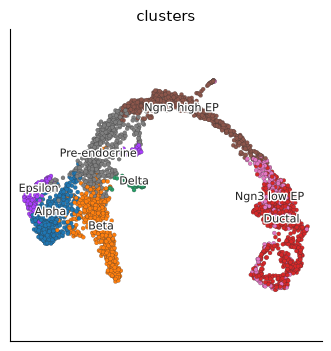

In [3]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    default_assay='RNA',
)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
    legend_loc='on_data',
)

In [4]:
progenitors = ['Ductal']
terminal_cell_types = ['Alpha', 'Beta', 'Delta']

ds.cells.to_pandas_dataframe(
    ['clusters'],
    key='I'
)['clusters'].value_counts()

clusters
Ductal           733
Ngn3 high EP     624
Pre-endocrine    585
Beta             573
Alpha            454
Ngn3 low EP      233
Epsilon          141
Delta             70
Name: count, dtype: int64

In [5]:
pseudotime = ds.run_pseudotime_scoring(
    source_sink_key='clusters',
    sources=progenitors,
    sinks=terminal_cell_types,
    label='fate_pseudotime',
)

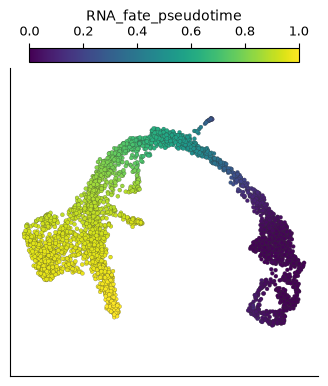

In [6]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=pseudotime.pseudotime_key,
    subset_by=pseudotime.validity_key,
)

In [7]:
fate = ds.run_fate_mapping(
    cell_key='I',
    subset_cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
    sink_key='clusters',
    sinks=terminal_cell_types,
)

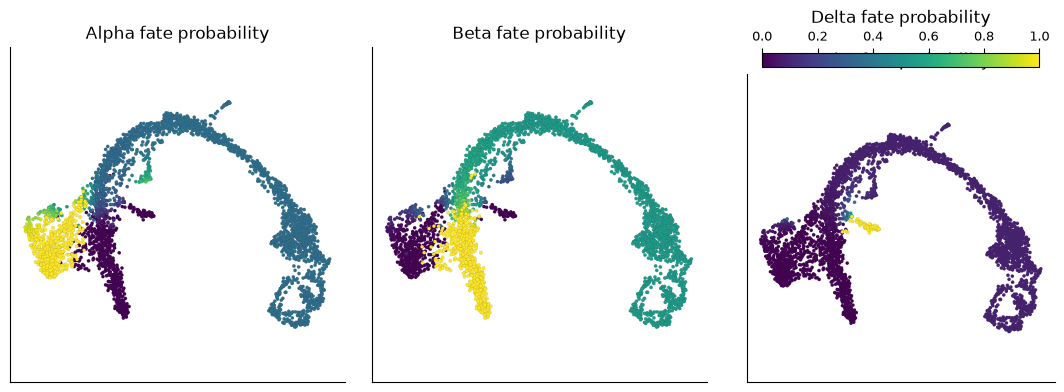

In [8]:
figure, axes = plt.subplots(1, 3, figsize=(11, 4))
probability_scale = splt.ColorScale(vmin=0, vmax=1)
for index, (axis, sink, fate_key) in enumerate(
    zip(axes, fate.sink_labels, fate.fate_keys, strict=True)
):
    ds.plots.embedding(
        layout_key="RNA_UMAP",
        color_by=fate_key,
        subset_by=fate.validity_key,
        color_scale=probability_scale,
        sort_values=True,
        show_legend=index == 2,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(f"{sink} fate probability")
for colorbar_axis in set(figure.axes) - set(axes):
    colorbar_axis.set_title(f"{fate.sink_labels[-1]} fate probability")
    colorbar_axis.set_xlabel("")
    colorbar_axis.set_ylabel("")
figure.tight_layout()
figure